<a href="https://colab.research.google.com/github/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network/blob/main/Find%20trials%20uncorrectly%20labeled%20grouped%20by%20animal_session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
!{sys.executable} -m pip install -U pip --quiet
!{sys.executable} -m pip install motornet --quiet
!{sys.executable} -m pip install git+https://github.com/OlivierCodol/MotorNet.git --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install --no-cache-dir --force-reinstall --no-deps \
    git+https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git
!pip install pynapple --quiet

  Cloning https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git to /tmp/pip-req-build-appzdl_1
  Running command git clone --filter=blob:none --quiet https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git /tmp/pip-req-build-appzdl_1
  Resolved https://github.com/lilytong0919/NMA-shichimi-rulebreakerhalf-comparing-network.git to commit 9b11b69d05e52b55d0de70569983d81a7cece2c8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for monkeypaw: filename=monkeypaw-0.1.0-py3-none-any.whl size=6092 sha256=8e97d11e07cf0a1d303a4b81cc294672d761ad1ab4cffd1de8364d81d97314f1
  Stored in directory: /tmp/pip-ephem-wheel-cache-jp9r9_r2/wheels/c5/4d/e0/f4cdde16d1079b6e82b4e94fb243e7e447475b8f6c6ad15d9c
Successfully built monkeypaw
  Attempting uninstall: monkeypaw
    Found existing installation: monkeypaw 0.1.0
    Uninstalling monkeypaw-0.1.0:
   

In [ ]:
!pip install dandi --quiet

In [ ]:
!python3 -m pip install pynapple --quiet

In [ ]:

from google.colab import drive
import monkeypaw.io as mpio
import pandas as pd
from dandi.download import download as dandi_download
import os
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt

# 2. Mount Google Drive for persistent storage
drive.mount('/content/drive')

# 3. Define a dedicated folder inside your Google Drive
drive_data_dir = "/content/drive/MyDrive/Dandi_Datasets/data"
os.makedirs(drive_data_dir, exist_ok=True)

filenames = [
    "sub-Dataset-3-Animals-1-to-4",
    "sub-Dataset-4-Animal-2-sess-1-to-7",
    "sub-Dataset-4-Animal-2-sess-8-to-12",
    "sub-Dataset-4-Animal-3-sess-1-to-6",
    "sub-Dataset-4-Animal-3-sess-7-to-11",
    "sub-Dataset-5-Animal-1",
    "sub-Dataset-5-Animals-2-ses-1-to-19",
    "sub-Dataset-5-Animals-2-ses-20-to-39",
    "sub-Dataset-5-Animals-2-ses-40-to-51",
    "sub-Dataset-5-Animals-3&4"
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
url_base = 'https://dandiarchive.org/dandiset/001057/draft/files?location='

# 4. Check if the directory already has files to avoid starting the dandi client
if os.path.exists(drive_data_dir) and len(os.listdir(drive_data_dir)) >= len(filenames):
    print("✨ All files are already saved in Google Drive! Skipping download loop.")
else:
    print("⏳ Files missing. Running DANDI download loop straight to Google Drive...")
    for filename in filenames:
        url = url_base + filename
        # Downloads directly into your persistent Drive folder
        dandi_download(
            [url],
            output_dir=drive_data_dir,
            existing="skip"
        )
    print("✅ Download complete and saved to Google Drive.")


✨ All files are already saved in Google Drive! Skipping download loop.


**Shared keys between 3 dataset are also:** (different spelling)
- 'EventTarget_Onset' (dataset 3 and 4), 'EventTarget_onset'(dataset 5)
- 'target_dir'(dataset 3 and 4), 'targets_dir'(dataset 5)

Shared keys only between dataset 4 and 5:
- 'cursor_vel_y',  'cursor_vel_x', 'cursor_pos_y', 'cursor_pos_x',  'cursor_acc_y',  'cursor_acc_x'

**Also between dataset 4 and 5:** (different spelling)
- 'target_ID' (dataset 4), 'Target_ID'(dataset 5)

In [ ]:
#dataset file id
id_file= 0
path = os.path.join(drive_data_dir,filenames[id_file],filenames[id_file]+'.nwb')
print(path)
dat1 = mpio.nap_load_data(os.path.join(drive_data_dir,filenames[id_file],filenames[id_file]+'.nwb'))

/content/drive/MyDrive/Dandi_Datasets/data/sub-Dataset-3-Animals-1-to-4/sub-Dataset-3-Animals-1-to-4.nwb
Original keys: ['spikes_counts', 'trial_id', 'session', 'datasetID', 'animal', 'result', 'EventTarget_Onset', 'EventMovement_start', 'EventGo_cue', 'target_dir', 'hand_vel_y', 'hand_vel_x', 'date', 'brain_region']


In [ ]:
dat1

sub-Dataset-3-Animals-1-to-4
┍━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━┑
│ Keys                │ Type     │
┝━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━┥
│ spikes_counts       │ TsdFrame │
│ trial_id            │ Tsd      │
│ session             │ Tsd      │
│ datasetID           │ Tsd      │
│ animal              │ Tsd      │
│ result              │ Tsd      │
│ EventTarget_Onset   │ Tsd      │
│ EventMovement_start │ Tsd      │
│ EventGo_cue         │ Tsd      │
│ target_dir          │ Tsd      │
│ hand_vel_y          │ Tsd      │
│ hand_vel_x          │ Tsd      │
│ date                │ Tsd      │
│ brain_region        │ Tsd      │
┕━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━┙

In [ ]:
dat1_info = mpio.get_info(dat1)
dat1_info

Time (s)              trial_id    animal    datasetID    session  brain_region
------------------  ----------  --------  -----------  ---------  --------------
0.0                          1         1            3          1  M1
0.03                         1         1            3          1  M1
0.06                         1         1            3          1  M1
0.09                         1         1            3          1  M1
0.12                         1         1            3          1  M1
0.15                         1         1            3          1  M1
0.18                         1         1            3          1  M1
...
32235.059999999998         465         3            3          3  Area2
32235.089999999997         465         3            3          3  Area2
32235.12                   465         3            3          3  Area2
32235.149999999998         465         3            3          3  Area2
32235.179999999997         465         3            3          3 

In [ ]:
dat1_behav = mpio.get_behav(dat1)
dat1_behav

Time (s)            EventGo_cue    EventTarget_Onset      target_ID    target_dir  result    ...
------------------  -------------  -------------------  -----------  ------------  --------  -----
0.0                 False          False                        nan       0        R         ...
0.03                False          False                        nan       0        R         ...
0.06                False          False                        nan       0        R         ...
0.09                False          False                        nan       0        R         ...
0.12                False          False                        nan       0        R         ...
0.15                False          False                        nan       0        R         ...
0.18                False          False                        nan       0        R         ...
...                                                                                          ...
32235.059999999998  False   

In [ ]:
merged_dat1_df = pd.merge(dat1_info.as_dataframe(), dat1_behav.as_dataframe(), left_index=True, right_index=True, how='outer', suffixes=('_info', '_behav'))

merged_dat1_df = merged_dat1_df.reset_index()
merged_dat1_df = merged_dat1_df.rename(columns={'index': 'time_s'})
display(merged_dat1_df)

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
0,0.00,1,1,3,1,M1,False,False,NaN,0.0,R,NaN,NaN,NaN,NaN,NaN,NaN
1,0.03,1,1,3,1,M1,False,False,NaN,0.0,R,NaN,NaN,NaN,NaN,NaN,NaN
2,0.06,1,1,3,1,M1,False,False,NaN,0.0,R,NaN,NaN,NaN,NaN,NaN,NaN
3,0.09,1,1,3,1,M1,False,False,NaN,0.0,R,NaN,NaN,NaN,NaN,NaN,NaN
4,0.12,1,1,3,1,M1,False,False,NaN,0.0,R,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074504,32235.12,465,3,3,3,Area2,False,False,NaN,3.141593,R,NaN,NaN,NaN,NaN,NaN,NaN
1074505,32235.15,465,3,3,3,Area2,False,False,NaN,3.141593,R,NaN,NaN,NaN,NaN,NaN,NaN
1074506,32235.18,465,3,3,3,Area2,False,False,NaN,3.141593,R,NaN,NaN,NaN,NaN,NaN,NaN
1074507,32235.21,465,3,3,3,Area2,False,False,NaN,3.141593,R,NaN,NaN,NaN,NaN,NaN,NaN


## Select animal

If column 'animal' is a string array

In [ ]:
animal_selected = 4
if type(merged_dat1_df['animal'][0]) == str:
  animal_selected = str(animal_selected)

type(animal_selected)

int

In [ ]:
anix_dat1_df = merged_dat1_df[merged_dat1_df['animal']==animal_selected]
anix_dat1_df

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
484339,14530.17,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
484340,14530.20,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
484341,14530.23,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
484342,14530.26,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
484343,14530.29,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872450,26173.50,216,4,3,6,PMd,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
872451,26173.53,216,4,3,6,PMd,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
872452,26173.56,216,4,3,6,PMd,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
872453,26173.59,216,4,3,6,PMd,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN


### Plotting Cursor Trajectory Function

`plot_cursor_trajectory` calculates target direction and plots the cursor trajectory, along with event markers. It takes `df_gpb_session_trial` as its only argument.

In [ ]:
def plot_cursor_trajectory(df_gpb_session_trial):

    if df_gpb_session_trial.empty:
        print("DataFrame is empty, cannot plot trajectory.")
        return

    # Check if cursor position data is all NaN
    if df_gpb_session_trial['cursor_pos_x'].isnull().all() or df_gpb_session_trial['cursor_pos_y'].isnull().all():
        print(f"Warning: No valid cursor position data (cursor_pos_x or cursor_pos_y are all NaN) for Animal {df_gpb_session_trial['animal'].iloc[0]}, Session {df_gpb_session_trial['session'].iloc[0]}, Trial {df_gpb_session_trial['trial_id'].iloc[0]}. Plotting axes with default limits.")

        plt.figure(figsize=(8, 8))
        plt.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=0)
        plt.axvline(0, color='black', linewidth=1.5, linestyle='-', zorder=0)

        # default limits when no cursor data
        default_limit = 10.0 # default for cursor positions
        plt.xlim(-default_limit, default_limit)
        plt.ylim(-default_limit, default_limit)

        plt.xlabel('Cursor Position X (cm)')
        plt.ylabel('Cursor Position Y (cm)')

        result_dic = {'R':'Rewarded','A':'Aborted','F':'Failed','I':'Incomplete'}
        # Ensure 'result' exists and is not empty
        if not df_gpb_session_trial['result'].empty:
            result_str = result_dic.get(df_gpb_session_trial['result'].iloc[0], 'Unknown')
        else:
            result_str = 'N/A'

        # line for target direction
        unique_target_dirs_rad = df_gpb_session_trial['target_dir'].unique()
        unique_target_dirs_deg = [np.degrees(direction) for direction in unique_target_dirs_rad]
        if unique_target_dirs_deg:
            target_angle_rad = np.radians(unique_target_dirs_deg[0])
            line_length = 15
            target_line_x = [0, line_length * np.cos(target_angle_rad)]
            target_line_y = [0, line_length * np.sin(target_angle_rad)]
            plt.plot(target_line_x, target_line_y, linestyle='--', color='yellow', linewidth=2, zorder=1, label=f'Target Direction ({unique_target_dirs_deg[0]:.0f}°)')

        plt.title(f"Cursor Trajectory for Dataset {df_gpb_session_trial['datasetID'].iloc[0]}: Animal {df_gpb_session_trial['animal'].iloc[0]}, Session {df_gpb_session_trial['session'].iloc[0]}, Trial {df_gpb_session_trial['trial_id'].iloc[0]} - Target {int(unique_target_dirs_deg[0])}°, result {result_str}")
        plt.grid(True)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()
        return


    # Calculate unique target directions
    unique_target_dirs_rad = df_gpb_session_trial['target_dir'].unique()
    unique_target_dirs_deg = [np.degrees(direction) for direction in unique_target_dirs_rad]
    print('Target direction for session ',df_gpb_session_trial['session'].unique()[0],', trial ', df_gpb_session_trial['trial_id'].unique()[0],': ', unique_target_dirs_deg[0], ' degrees')

    plt.figure(figsize=(8, 8))

    # Get trial start time
    trial_start_time = df_gpb_session_trial['time_s'].iloc[0]

    # Draw darker axis lines at 0,0
    plt.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=0)
    plt.axvline(0, color='black', linewidth=1.5, linestyle='-', zorder=0)

    plt.plot(df_gpb_session_trial['cursor_pos_x'], df_gpb_session_trial['cursor_pos_y'], marker='.', linestyle='-', label='Cursor Trajectory')
    plt.plot(df_gpb_session_trial['cursor_pos_x'].iloc[0], df_gpb_session_trial['cursor_pos_y'].iloc[0], marker='*', color='red', markersize=15, label='Start Point')

    # Mark EventTarget_Onset points
    target_onset_rows = df_gpb_session_trial[df_gpb_session_trial['EventTarget_Onset'] == True]
    target_onset_x = target_onset_rows['cursor_pos_x']
    target_onset_y = target_onset_rows['cursor_pos_y']
    if not target_onset_rows.empty:
        relative_target_onset_time = target_onset_rows['time_s'].iloc[0] - trial_start_time
        plt.plot(target_onset_x, target_onset_y, 'o', color='green', markersize=10, label=f'Target Onset ({relative_target_onset_time:.2f} s)')
    else:
        plt.plot([], [], 'o', color='green', markersize=10, label='Target Onset (N/A)') # Plot empty if no events

    # Mark EventGo_cue points
    go_cue_rows = df_gpb_session_trial[df_gpb_session_trial['EventGo_cue'] == True]
    go_cue_x = go_cue_rows['cursor_pos_x']
    go_cue_y = go_cue_rows['cursor_pos_y']
    if not go_cue_rows.empty:
        relative_go_cue_time = go_cue_rows['time_s'].iloc[0] - trial_start_time
        plt.plot(go_cue_x, go_cue_y, 'x', color='purple', markersize=10, label=f'Go Cue ({relative_go_cue_time:.2f} s)')
    else:
        plt.plot([], [], 'x', color='purple', markersize=10, label='Go Cue (N/A)') # Plot empty if no events

    # Mark the endpoint
    endpoint_row = df_gpb_session_trial.iloc[-1]
    endpoint_x = endpoint_row['cursor_pos_x']
    endpoint_y = endpoint_row['cursor_pos_y']
    relative_endpoint_time = endpoint_row['time_s'] - trial_start_time
    plt.plot(endpoint_x, endpoint_y, 's', color='blue', markersize=10, label=f'Endpoint ({relative_endpoint_time:.2f} s)')

    # Calculate symmetric ranges for x and y axes centered at 0
    x_min_data = df_gpb_session_trial['cursor_pos_x'].min()
    x_max_data = df_gpb_session_trial['cursor_pos_x'].max()
    y_min_data = df_gpb_session_trial['cursor_pos_y'].min()
    y_max_data = df_gpb_session_trial['cursor_pos_y'].max()

    # Determine the maximum absolute value among all min/max data points
    max_abs_val = max(abs(x_min_data), abs(x_max_data), abs(y_min_data), abs(y_max_data))+0.5

    # Set new symmetric limits based on the maximum absolute value, centered at 0
    plt.xlim(-max_abs_val, max_abs_val)
    plt.ylim(-max_abs_val, max_abs_val)

    # Add line for target direction
    if unique_target_dirs_deg:
        target_angle_rad = np.radians(unique_target_dirs_deg[0])
        line_length = max_abs_val * 1.5
        target_line_x = [0, line_length * np.cos(target_angle_rad)]
        target_line_y = [0, line_length * np.sin(target_angle_rad)]
        plt.plot(target_line_x, target_line_y, linestyle='--', color='yellow', linewidth=2, zorder=1, label=f'Target Direction ({unique_target_dirs_deg[0]:.0f}°)')

    result_dic = {'R':'Rewarded','A':'Aborted','F':'Failed','I':'Incomplete'}
    result_str = result_dic[df_gpb_session_trial['result'].iloc[0]]

    plt.xlabel('Cursor Position X (cm)')
    plt.ylabel('Cursor Position Y (cm)')
    plt.title(f"Cursor Trajectory for Dataset {df_gpb_session_trial['datasetID'].iloc[0]}: Animal {df_gpb_session_trial['animal'].iloc[0]}, Session {df_gpb_session_trial['session'].iloc[0]}, Trial {df_gpb_session_trial['trial_id'].iloc[0]} - Target {int(unique_target_dirs_deg[0])}°, result {result_str}")
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box') # Equal scaling for x and y axes
    plt.legend()
    plt.show()

### Plotting Events Over Time Function

`plot_events_over_time` displays the occurrences of events ('EventTarget_Onset', 'EventGo_cue') as vertical lines on a time-series plot for a given animal, session, and trial. The time will be relative to the start of the trial.

In [ ]:
def plot_events_over_time(df_gpb_session_trial):

    if df_gpb_session_trial.empty:
        print("DataFrame is empty, cannot plot events.")
        return

    # Get trial start time for relative timing
    trial_start_time = df_gpb_session_trial['time_s'].iloc[0]

    # Prepare event data
    events = {
        'EventTarget_Onset': 'green',
        'EventGo_cue': 'purple'
    }

    plt.figure(figsize=(12, 4))

    # Add line for the start of the trial
    plt.axvline(0, color='blue', linestyle='-', linewidth=2, label='Trial Start (Relative: 0.00 s)')

    # Plot events as vertical lines
    for event_name, color in events.items():
        event_times = df_gpb_session_trial[df_gpb_session_trial[event_name] == True]['time_s']
        if not event_times.empty:
            for t in event_times:
                relative_time = t - trial_start_time
                plt.axvline(relative_time, color=color, linestyle='--', label=f'{event_name} (Relative: {relative_time:.2f} s)')

    # Add line for the end of the trial
    trial_end_time = df_gpb_session_trial['time_s'].iloc[-1]
    relative_trial_end_time = trial_end_time - trial_start_time
    plt.axvline(relative_trial_end_time, color='red', linestyle='-', linewidth=2, label=f'Trial End (Relative: {relative_trial_end_time:.2f} s)')

    # Set title and labels
    animal = df_gpb_session_trial['animal'].iloc[0]
    session = df_gpb_session_trial['session'].iloc[0]
    trial_id = df_gpb_session_trial['trial_id'].iloc[0]
    dataset_id = df_gpb_session_trial['datasetID'].iloc[0]
    target_dg = int(np.degrees(df_gpb_session_trial['target_dir'].iloc[0]))

    plt.title(f'Events Over Time for Dataset {dataset_id}: Animal {animal}, Session {session}, Trial {trial_id} - Target {target_dg}°')
    plt.xlabel('Time Relative to Trial Start (s)')
    plt.ylabel('Event Occurrence')
    plt.yticks([]) # Remove y-axis ticks as they are not needed
    plt.legend()
    plt.grid(True)
    plt.show()

### Combined Function to Plot Events by Brain Region
Plots events over time for 'M1', 'PMd', 'Area2' and NaN brain regions separately
from a given DataFrame.


In [33]:
def plot_events_by_brain_region(df):
    """
    Plots events over time for 'M1', 'PMd', 'Area2' and NaN brain regions separately
    from a given DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing trial data with 'brain_region' column.
    """

    # Plot for M1 brain region
    m1_df = df[df['brain_region'] == 'M1']
    if not m1_df.empty:
        print("\nPlotting events for M1 Brain Region:")
        plot_events_over_time(m1_df)
    else:
        print("\nNo data found for M1 Brain Region.")

    # Plot for PMd brain region
    pmd_df = df[df['brain_region'] == 'PMd']
    if not pmd_df.empty:
        print("\nPlotting events for PMd Brain Region:")
        plot_events_over_time(pmd_df)
    else:
        print("\nNo data found for PMd Brain Region.")

    # Plot for Area2 brain region
    pmd_df = df[df['brain_region'] == 'Area2']
    if not pmd_df.empty:
        print("\nPlotting events for Area2 Brain Region:")
        plot_events_over_time(pmd_df)
    else:
        print("\nNo data found for Area2 Brain Region.")

    # Plot for NaN brain region
    nan_brain_region_df = df[df['brain_region'].isnull()]
    if not nan_brain_region_df.empty:
        print("\nPlotting events for NaN Brain Region:")
        plot_events_over_time(nan_brain_region_df)
    else:
        # Check if 'brain_region' column exists and has non-NaN values
        if 'brain_region' in df.columns and not df['brain_region'].isnull().all():
            print("\nNo NaN brain region data found in the current DataFrame for plotting.")
        else:
            print("\n'brain_region' column is either missing or entirely NaN. No NaN brain region plots to generate.")


### Selecting session and trial for animal x
Now we define `df_gpb_session_trial`

In [ ]:
session_selected = 1
if type(merged_dat1_df['session'][0]) == str:
  session_selected = str(session_selected)
trial_selected = 1
if type(merged_dat1_df['trial_id'][0]) == str:
  trial_selected = str(trial_selected)

df_gpb_session_trial = anix_dat1_df[(anix_dat1_df['session'] == session_selected) & (anix_dat1_df['trial_id'] == trial_selected)]
df_gpb_session_trial

,time_s,trial_id,animal,datasetID,session,brain_region,EventGo_cue,EventTarget_Onset,target_ID,target_dir,result,cursor_pos_x,cursor_pos_y,cursor_vel_x,cursor_vel_y,cursor_acc_x,cursor_acc_y
484339,14530.17,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
484340,14530.20,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
484341,14530.23,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
484342,14530.26,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
484343,14530.29,1,4,3,1,M1,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678547,20356.41,1,4,3,1,PMd,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
678548,20356.44,1,4,3,1,PMd,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
678549,20356.47,1,4,3,1,PMd,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN
678550,20356.50,1,4,3,1,PMd,False,False,NaN,0.785398,R,NaN,NaN,NaN,NaN,NaN,NaN


### Plotting time events by brain region
We call the `plot_events_by_brain_region` function using the `df_gpb_session_trial`as input. This will show the timing of the specified events within that trial.


Plotting events for M1 Brain Region:


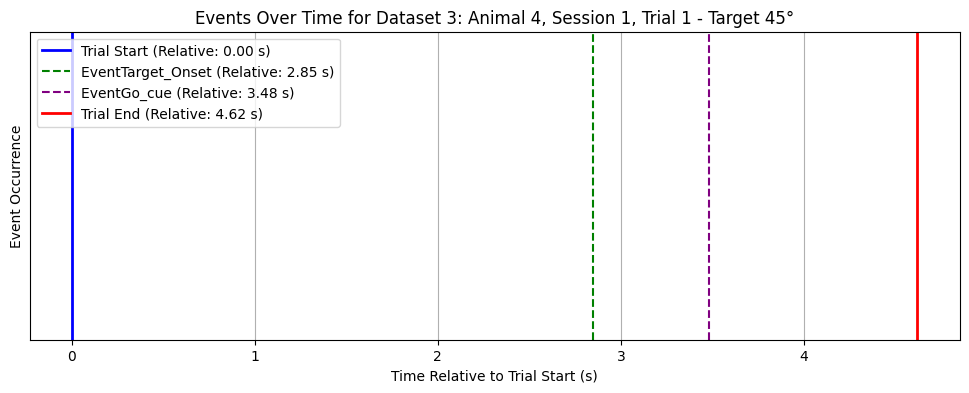


Plotting events for PMd Brain Region:


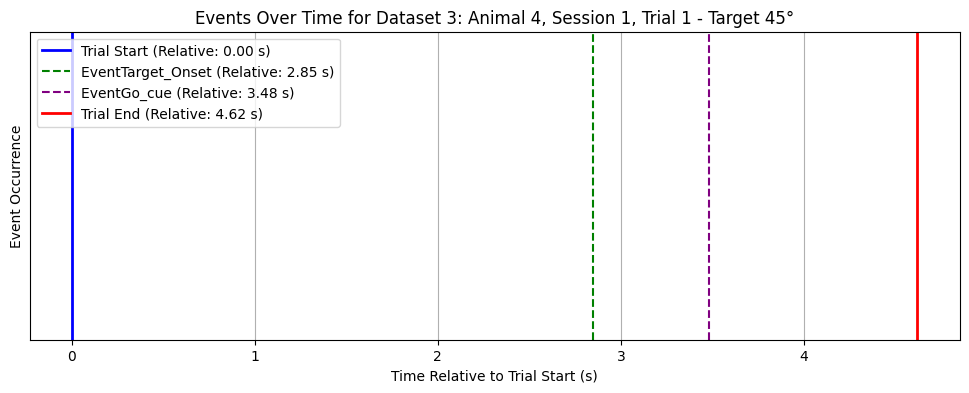


No data found for Area2 Brain Region.

No NaN brain region data found in the current DataFrame for plotting.


In [ ]:
plot_events_by_brain_region(df_gpb_session_trial)

## Plotting cursor trajectory

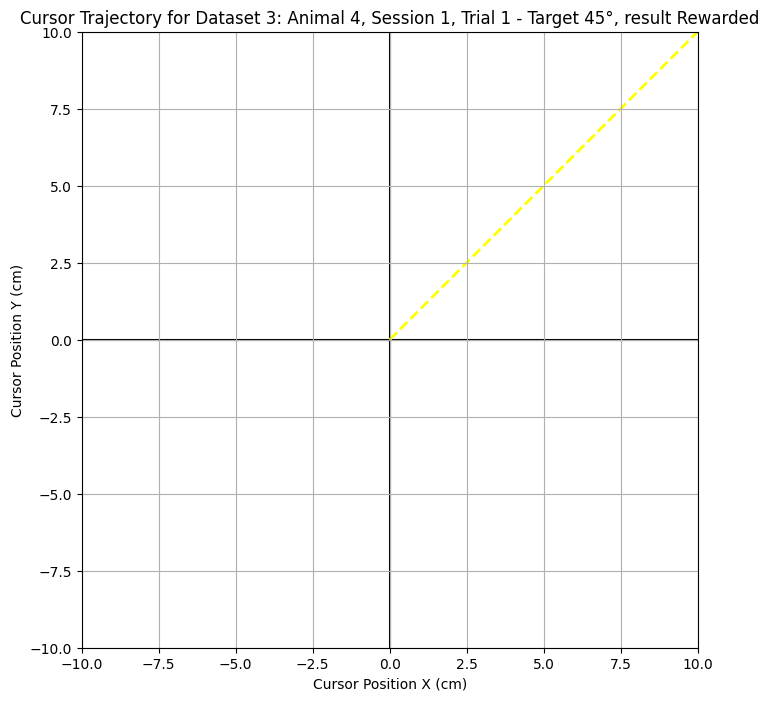

In [ ]:
plot_cursor_trajectory(df_gpb_session_trial)

In [ ]:
unique_target_ids = anix_dat1_df['target_ID'].dropna().unique()

for target_id in unique_target_ids:
    unique_target_dirs_rad = anix_dat1_df[anix_dat1_df['target_ID'] == target_id]['target_dir'].unique()
    # Convert to degrees, handling potential NaN values
    unique_target_dirs_deg = [np.degrees(d) if not pd.isna(d) else np.nan for d in unique_target_dirs_rad]
    print(f"Unique target_dir values for target_ID = {target_id} (degrees):")
    display(np.array(unique_target_dirs_deg))

In [ ]:
[np.degrees(d) if not pd.isna(d) else np.nan for d in anix_dat1_df['target_dir'].dropna().unique()]

[np.float64(45.0),
 np.float64(225.0),
 np.float64(180.0),
 np.float64(270.0),
 np.float64(135.0),
 np.float64(315.0),
 np.float64(90.0),
 np.float64(0.0)]

## Find incorrectly labeled rewarded trials (`result = 'R'`)
Identifies trials labeled as 'Rewarded' ('R') that violate specified criteria,
considering each brain region segment (if present) separately within a trial.

Criteria:
1. `EventTarget_Onset` or `EventGo_cue` cursor positions are outside
       a specified radial threshold from (0,0).
2. Duration from `EventGo_cue` to the end of the trial segment is not within
       (duration_expected).
3. The cursor's endpoint direction for the trial segment is not within angle_tolerance_deg of the `target_dir`.

Parameters:
- pos_threshold_cm= 2,
- duration_expected_s= 3.0,
- angle_tolerance_deg= 20

In [ ]:
import pandas as pd
import numpy as np

def find_incorrectly_labeled_rewarded_trials(df,
                                             pos_threshold_cm=2,
                                             duration_expected_s=3.0,
                                             angle_tolerance_deg=20):
    """
    Identifies trials labeled as 'Rewarded' ('R') that violate specified criteria,
    considering each brain region segment (if present) separately within a trial.

    Criteria:
    1. 'EventTarget_Onset' or 'EventGo_cue' cursor positions are outside
       a specified radial threshold from (0,0).
    2. Duration from 'EventGo_cue' to the end of the trial segment is not within
       (duration_expected).
    3. The cursor's endpoint direction for the trial segment is not within angle_tolerance_deg of the target_dir.

    Args:
        df (pd.DataFrame): The DataFrame containing trial data.
        pos_threshold_cm (int): Max distance from (0,0) for target onset/go cue.
        duration_expected_s (float): Expected duration from go cue to the end of the trial segment.
        angle_tolerance_deg (float): Allowed deviation for endpoint angle from target direction.

    Returns:
        pd.DataFrame: A DataFrame listing 'Rewarded' trials that violate any criteria,
                      organised by animal, session, trial_id, and detailing if any brain regions
                      caused the violation, along with event presence.
    """
    all_incorrect_segments = []
    angle_tolerance_rad = np.radians(angle_tolerance_deg)
    max_expected_duration = duration_expected_s

    # Group by trial_id and brain_region to evaluate each segment separately
    # dropna=False ensures NaN brain_regions are treated as a distinct group
    grouped_segments = df.groupby(['animal', 'session', 'trial_id', 'brain_region'], dropna=False)

    for group_keys, segment_df in grouped_segments:
        animal, session, trial_id, brain_region = group_keys

        # Only process trial segments labeled as 'Rewarded'
        if 'R' not in segment_df['result'].unique():
            continue

        is_incorrect_segment = False
        segment_reasons = []

        # Initialize metrics for this trial segment
        dist_target_onset_seg = np.nan
        dist_go_cue_seg = np.nan
        actual_duration_from_go_cue_seg = np.nan
        endpoint_angle_seg_deg = np.nan
        target_direction_seg_deg = np.nan

        # Determine event presence
        target_onset_event_rows = segment_df[segment_df['EventTarget_Onset'] == True]
        go_cue_event_rows = segment_df[segment_df['EventGo_cue'] == True]
        has_target_onset_event_seg = not target_onset_event_rows.empty
        has_go_cue_event_seg = not go_cue_event_rows.empty

        # Check if cursor position columns exist and have non-NaN values
        cursor_data_present = 'cursor_pos_x' in segment_df.columns and \
                              not segment_df['cursor_pos_x'].isnull().all() and \
                              not segment_df['cursor_pos_y'].isnull().all()

        # --- Criterion 1: Target Onset / Go Cue position ---
        if cursor_data_present:
            if has_target_onset_event_seg:
                target_onset_x = target_onset_event_rows['cursor_pos_x'].iloc[0]
                target_onset_y = target_onset_event_rows['cursor_pos_y'].iloc[0]
                if not np.isnan(target_onset_x) and not np.isnan(target_onset_y):
                    dist_target_onset_seg = np.sqrt(target_onset_x**2 + target_onset_y**2)
                    if dist_target_onset_seg > pos_threshold_cm:
                        is_incorrect_segment = True
                        segment_reasons.append(f"Target Onset dist ({dist_target_onset_seg:.2f}cm) > {pos_threshold_cm}cm")

            if has_go_cue_event_seg:
                go_cue_x = go_cue_event_rows['cursor_pos_x'].iloc[0]
                go_cue_y = go_cue_event_rows['cursor_pos_y'].iloc[0]
                if not np.isnan(go_cue_x) and not np.isnan(go_cue_y):
                    dist_go_cue_seg = np.sqrt(go_cue_x**2 + go_cue_y**2)
                    if dist_go_cue_seg > pos_threshold_cm:
                        is_incorrect_segment = True
                        segment_reasons.append(f"Go Cue dist ({dist_go_cue_seg:.2f}cm) > {pos_threshold_cm}cm")
        else:
            segment_reasons.append("Cursor position data missing for initial position check")

        # --- Criterion 2: Duration from Go Cue to End of Trial Segment --- (requires Go_cue event)
        # may add duration from target_onset event to end of trial segment later
        if has_go_cue_event_seg:
            go_cue_time = go_cue_event_rows['time_s'].iloc[0]
            # 'End of trial segment' means the last timestamp in this specific segment_df
            segment_end_time = segment_df['time_s'].iloc[-1]
            actual_duration_from_go_cue_seg = segment_end_time - go_cue_time
            if not (actual_duration_from_go_cue_seg <= max_expected_duration):
                is_incorrect_segment = True
                segment_reasons.append(f"Go Cue to End of trial duration ({actual_duration_from_go_cue_seg:.2f}s) higher than {max_expected_duration:.2f}s")
        else:
            segment_reasons.append("Go Cue event missing, cannot check duration")

        # --- Criterion 3: Endpoint direction relative to Target Direction ---
        if cursor_data_present and 'target_dir' in segment_df.columns and not pd.isna(segment_df['target_dir'].iloc[0]):
            endpoint_x = segment_df['cursor_pos_x'].iloc[-1]
            endpoint_y = segment_df['cursor_pos_y'].iloc[-1]
            target_direction_rad = segment_df['target_dir'].iloc[0]

            if not np.isnan(endpoint_x) and not np.isnan(endpoint_y):
                endpoint_angle_rad = np.arctan2(endpoint_y, endpoint_x)

                # Calculate angular difference, normalizing to -pi to pi
                angle_diff_rad = np.arctan2(np.sin(endpoint_angle_rad - target_direction_rad), np.cos(endpoint_angle_rad - target_direction_rad))

                endpoint_angle_seg_deg = np.degrees(endpoint_angle_rad)
                target_direction_seg_deg = np.degrees(target_direction_rad)

                if np.abs(angle_diff_rad) > angle_tolerance_rad:
                    is_incorrect_segment = True
                    segment_reasons.append(f"Endpoint angle ({endpoint_angle_seg_deg:.1f}°) not ~Target ({target_direction_seg_deg:.1f}°, diff {np.degrees(angle_diff_rad):.1f}°)")
            else:
                segment_reasons.append("Endpoint cursor position missing for angle check")
        else:
            segment_reasons.append("Cursor data or target direction missing for angle check")

        # If this segment was flagged, record its details
        if is_incorrect_segment:
            all_incorrect_segments.append({
                'animal': animal,
                'session': session,
                'trial_id': trial_id,
                'brain_region_flagged': brain_region if pd.notna(brain_region) else 'NaN',
                'result_label': 'R',
                'target_onset_dist_cm': dist_target_onset_seg,
                'go_cue_dist_cm': dist_go_cue_seg,
                'duration_from_go_cue_s': actual_duration_from_go_cue_seg,
                'endpoint_angle_deg': endpoint_angle_seg_deg,
                'target_direction_deg': target_direction_seg_deg,
                'has_target_onset_event': has_target_onset_event_seg,
                'has_go_cue_event': has_go_cue_event_seg,
                'reasons_seg': '; '.join(segment_reasons)
            })

    if not all_incorrect_segments:
        return pd.DataFrame() # Return empty DataFrame if no segments were incorrect

    # Convert to DataFrame of incorrect segments
    incorrect_segments_df = pd.DataFrame(all_incorrect_segments)

    # Consolidate results by trial (animal, session, trial_id)
    # If any segment within a trial is incorrect, the trial is incorrect.
    # Aggregate brain regions and reasons, taking first non-NaN metric value.
    consolidated_incorrect_trials = incorrect_segments_df.groupby(['animal', 'session', 'trial_id']).agg(
        result_label=('result_label', 'first'),
        brain_regions_in_trial=('brain_region_flagged', lambda x: ', '.join(sorted(x.unique()))),
        target_onset_dist_cm=('target_onset_dist_cm', lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan),
        go_cue_dist_cm=('go_cue_dist_cm', lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan),
        duration_from_go_cue_s=('duration_from_go_cue_s', lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan),
        endpoint_angle_deg=('endpoint_angle_deg', lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan),
        target_direction_deg=('target_direction_deg', lambda x: x.dropna().iloc[0] if not x.dropna().empty else np.nan),
        has_target_onset_event=('has_target_onset_event', 'any'), # True if any segment had the event
        has_go_cue_event=('has_go_cue_event', 'any'), # True if any segment had the event
        reasons=('reasons_seg', lambda x: '; '.join(sorted(x.unique()))),
    ).reset_index()

    return consolidated_incorrect_trials

In [ ]:
# Call the function with your animal-filtered DataFrame
incorrectly_labeled_trials_df = find_incorrectly_labeled_rewarded_trials(anix_dat1_df)
pos_cm_threshold =2
# Display the results
if not incorrectly_labeled_trials_df.empty:
    print(f"'Rewarded' trials violating one or more criteria (Initial Position > {pos_cm_threshold}cm, Go Cue duration not ~{duration_target_s}s, Endpoint angle not ~Target by {angle_tol_deg}°):")
    display(incorrectly_labeled_trials_df)
else:
    print(f"No 'Rewarded' trials found violating the specified criteria for animal {animal_selected}.")

No 'Rewarded' trials found violating the specified criteria for animal 4.


In [ ]:
np.shape(anix_dat1_df)

(388116, 17)

In [ ]:
anix_dat1_df['animal']

,animal
484339,4
484340,4
484341,4
484342,4
484343,4
...,...
872450,4
872451,4
872452,4
872453,4


In [ ]:
trials_per_session = anix_dat1_df.groupby('session')['trial_id'].nunique().reset_index()
trials_per_session.columns = ['session', 'number_of_trials']
print('For animal ', anix_dat1_df['animal'].iloc[0])
num_unique_trials = anix_dat1_df.groupby(['session', 'trial_id']).ngroups
print(f"Number of unique session and trial_id combinations: {num_unique_trials}")
display(trials_per_session)

For animal  4
Number of unique session and trial_id combinations: 1277


,session,number_of_trials
0,1,208
1,2,225
2,3,208
3,4,203
4,5,217
5,6,216


## Check for Event Presence per Trial

This function will iterate through each unique trial and determine if 'EventGo_cue' and 'EventTarget_Onset' events are present within that trial. It returns a DataFrame with boolean flags for each event per trial.

In [ ]:
def check_trial_events_presence(df):
    """
    Checks for the presence of 'EventGo_cue' and 'EventTarget_Onset' in each trial.

    Args:
        df (pd.DataFrame): DataFrame containing trial data.

    Returns:
        pd.DataFrame: DataFrame with 'animal', 'session', 'trial_id',
                      'has_go_cue_event', and 'has_target_onset_event' columns.
    """
    trial_event_presence = []

    grouped_trials = df.groupby(['animal', 'session', 'trial_id'])

    for (animal, session, trial_id), trial_df in grouped_trials:
        has_go_cue = (trial_df['EventGo_cue'] == True).any()
        has_target_onset = (trial_df['EventTarget_Onset'] == True).any()

        trial_event_presence.append({
            'animal': animal,
            'session': session,
            'trial_id': trial_id,
            'has_go_cue_event': has_go_cue,
            'has_target_onset_event': has_target_onset
        })

    return pd.DataFrame(trial_event_presence)




In [ ]:
trial_event_df = check_trial_events_presence(anix_dat1_df)
display(trial_event_df)

,animal,session,trial_id,has_go_cue_event,has_target_onset_event
0,4,1,1,True,True
1,4,1,2,True,True
2,4,1,3,True,True
3,4,1,4,True,True
4,4,1,5,True,True
...,...,...,...,...,...
1272,4,6,212,True,True
1273,4,6,213,True,True
1274,4,6,214,True,True
1275,4,6,215,True,True


### Trials without Go Cue or Target Onset Events

This table shows trials where either the 'EventGo_cue' or 'EventTarget_Onset' was not recorded.

In [ ]:
trials_without_events = trial_event_df[(trial_event_df['has_go_cue_event'] == False) | (trial_event_df['has_target_onset_event'] == False)]

if not trials_without_events.empty:
    print("dataset ", anix_dat1_df['datasetID'].iloc[0], ", animal ", anix_dat1_df['animal'].iloc[0],": Trials missing Go Cue or Target Onset events:")
    display(trials_without_events)
else:
    print("dataset ", anix_dat1_df['datasetID'].iloc[0], ", animal ", anix_dat1_df['animal'].iloc[0],": All trials have both Go Cue and Target Onset events.")

dataset  3 , animal  4 : All trials have both Go Cue and Target Onset events.


## Plot average of 1all trials in 1 target direction